<a id="top"></a>
# PanSTARRS "20 queries" using MAST's TAP service: Multiple detections


******

## Overview

This notebook is part of a series demonstrating how to address a set of scientific questions using SQL-like Astronomical Data Query Language (ADQL) queries via a Virtual Observatory standard Table Access Protocol (TAP) service at MAST. This series aims to be an introduction to how complex queries can be executed using TAP (which might otherwise not be possible to specify with `astroquery`), and to be a resource for how to access MAST databases after the MAST CASJobs service is retired. The presented queries are drawn from 20 queries for SDSS as presented by [Gray, Szalay, et al. (2002)](https://arxiv.org/abs/cs/0202014), adapted for the PanSTARRS PS1 database.

This notebook presents the subset of queries to **find & analyze objects with multiple detections**, by joining object-level and detection catalogs and applying filtering constraints.

For more examples of filtering techniques in TAP queries (including using bitmask filtering for data quality cuts), please see the [PS1 "20 queries" Basic Filtering tutorial](../PS1_20q_filtering_tutorial/PS1_20q_basic_filtering_tutorial.html).


## Learning Goals
By the end of this tutorial, you will:

- Understand how to identify and filter objects with multiple detections by joining tables using ADQL queries with TAP services.


****
### Table of Contents

* [Introduction](#Introduction)
* [Imports](#Imports)
* [Connect to TAP service](#Connect-to-TAP-service)
* [Q15: Provide a list of moving objects consistent with an asteroid.](#q15)
  * [Constructing the query](#q15:-constructing-the-query)
  * [Inspecting & visualizing the results](#q15:-inspecting-&-visualizing-the-results)
* [Conclusions](#conclusions)
* [Additional Resources](#additional-resources)
* [Citations](#citations)
* [About This Notebook](#about-this-notebook)

*******
## Introduction

Welcome! This notebook shows how to query MAST's PanSTARRS data using Astronomical Data Query Language (ADQL). Here we address scientific questions that rely on obtaining information regarding detections at multiple epochs, by joining object-level catalogs with the individual epoch detection catalog (together with relevant filtering). As you'll see in our examples, MAST uses a standard Table Access Protocol (TAP) to handle these queries.

These queries are taken from (or closely modeled on) the "20 queries for SDSS" presented by [Gray, Szalay, et al. (2002)](https://arxiv.org/abs/cs/0202014). Taken as a whole, this collection provides worked examples on how to leverage relational database capabilities to answer scientific questions, with the aim of providing concrete starting points and references for designing queries in other research applications, both for PanSTARRS and other large data volume missions (including Roman).

<div class="alert alert-block alert-info">
<b>Note:</b> ADQL/SQL comments follow "--". Comments are used throughout the queries to explain the purpose of specific clauses.
</div>

## Imports
This tutorial makes use of the following libraries: 
- [*numpy*](https://numpy.org/) for numerical calculations
- [*pyvo*](https://pyvo.readthedocs.io) for querying the MAST catalogs via TAP
- [*matplotlib.pyplot*](https://matplotlib.org/stable/api/pyplot_summary.html#module-matplotlib.pyplot) for plotting data
- *time*, *datetime* to determine query duration
- [*astropy.table Table*](https://docs.astropy.org/en/stable/table/index.html) to load comparison data table

In [1]:
import numpy as np
import pyvo as vo
import matplotlib.pyplot as plt
import datetime
import time
from astropy.table import Table

--------
## Connect to TAP service

We will be connecting to the Pan-STARRS (PS1) Data release 2 (DR2) catalog. Specifically, we will use the `ps1_dr2` catalogs available from the new [postgres-backed TAP service](https://mast.stsci.edu/vo-tap/api/v0.1/mast_catalogs/), which offers improved performance relative to the legacy database (by factors of 100 or greater, in many cases).

See the [PS1 documentation migration guide](https://outerspace.stsci.edu/x/DIFeGg) for information about the tables available with this new TAP service.


We begin by connecting to the MAST PanSTARRS DR2 TAP service.

_(Note: See https://mast.stsci.edu/vo-tap/ for a full list of MAST TAP services.)_

In [2]:
TAP_service = vo.dal.TAPService(
    "https://mast.stsci.edu/vo-tap/api/v0.1/mast_catalogs"
)

Using the pyvo `describe()` method, we can access an overview of the methods, capabilities, and maximum result set size for this service. 

In [3]:
TAP_service.describe()

Capability ivo://ivoa.net/std/TAP

Interface vs:ParamHTTP
    https://mast.stsci.edu/vo-tap/api/v0.1/mast_catalogs

Language ADQL
    ivo://ivoa.net/std/TAPRegExt#features-adqlgeo
        CONTAINS

        POINT

        CIRCLE


    ivo://edu.stsci.archive/std/exts#features-adql-bitwise
        BIT_AND
            The ampersand (&) operator performs a bitwise AND operation on two integer operands

        BIT_OR
            The vertical bar (|) operator performs a bitwise OR operation on two integer operands.

        BIT_XOR
            The circumflex (^) operator performs a bitwise XOR (exclusive or) operation on two integer operands.

        BIT_NOT
            The tilde (~) operator performs a bitwise NOT operation on an integer operand.


Output format application/json
    Also available as json

Output format text/csv;header=present
    Also available as csv

Output format application/xml
    Also available as xml

Output format application/x-votable+xml
    Also available as v

As expected, this service supports ADQL. You can also see the maximum result size is 100,000 rows.

## Obtaining information about PanSTARRS catalogs

In addition to the [PanSTARRS DR2 catalogs documentation](https://outerspace.stsci.edu/spaces/PANSTARRS/pages/298812351/PS1+Source+extraction+and+catalogs), 
we can search and explore information about the PS1 DR2 tables using **MAST's [Catalog Schema Browser](https://mast.stsci.edu/schema_browser)**. This schema browser provides searchable listings of column names, units, and descriptions for the PS1 DR2 tables available via this TAP service. _(The Catalog Schema Browser is also **integrated within TIKE/RRN**, and can be launched via its icon on the Launcher.)_

We draw on this documentation and schema browser to identify the relevant tables & columns needed to address the queries below.

*********

## Q15

Query 15 poses: 

> **Provide a list of moving objects consistent with an asteroid.**


### Q15: Constructing the query

In the PS1 survey strategy, a pair or quad of images is acquired in a single filter, separated by approximately 15 minutes --- allowing for the identification of fast-moving near-Earth objects. (See Section 3.2 of the PS1 survey paper, [Chambers et al. 2016](https://ui.adsabs.harvard.edu/abs/2016arXiv161205560C/abstract), for more details.)

While there is a special PS1 database associated with these fast-moving objects, it is not include as part of the MAST PS1 databases. However, the data in the MAST PS1 database can still be used to identify fast-moving objects. The PS1 observing strategy groups observations in the `z` and `y` bands into groups of 4 observations for each filter, with a total of 8 observations collected within a 22 minute interval.  If the object is moving extremely fast, its detections for the 8 observations will appear in the database as 8 separate objects, each with a single detection.  That happens when the spacing between individual object positions is more than 1 arcsec (corresponding to an object proper motion greater than about 20 arcsec/hour).  Such objects are difficult to identify via a database query because it is necessary to find groups of objects spread over a few arcseconds, requiring a self-match of the object table with itself (a slow process).

For somewhat slower moving objects, however, the observations in consecutive images overlap, producing database entries that have 2 or more measurements depending on how fast the object is moving.  A slower moving object can have up to 8 measurements (4 in z and 4 in y).  If an object has at least 3 detections, a proper motion is included in the PS1 DR2 `ps1_dr2.mean_object` or `ps1_dr2.stack_object` table ([see the documentation on the new TAP service](https://outerspace.stsci.edu/x/DIFeGg); in the legacy database, these are contained in the ObjectThin table).  The proper motion in these cases is vastly higher than the values for stars: the fastest moving star moves about 10 arcsec per year, while asteroids and other solar system objects can easily be moving by 10 arcsec per hour, nearly 10,000 times faster than the fastest stars.  


The query below searches for objects that move by more than 0.1 arcsec in 22 minutes (enough motion to have a chance of being detected by the PS1 pipeline).  It has many constraints to reduce contamination of the sample by spurious catalog sources:

- Require at least 4 detections (slightly more conservative than 3), with all detections in the `z` or `y` bands and zero detections in the `g`, `r`, or `i` bands.
- Require the range of times for all detections to be less than 1 hour.
- Require the proper motion to be greater than 0.1 arcsec of motion in 22 min
- Include only detection measurements of good quality: `psfqfperfect`>0.9 and `psfflux`>0 
- Exclude heavily resolved objects using the `kronflux`/`psfflux` ratio (because galaxies can have lower accuracy positions that mimic motion).
- Retain only observations with reasonably good resolution (psf FWHM <= 1.5 arcsec, for both major and minor axes).
- Require at least 4 remaining detections after the above constraints are applied.


Finally, we limit this query to objects in slice 16 (by requiring `objid` between 
129500000000000000 and 133500000000000000), to ensure the query does not exceed the time limit for a single TAP query.

We first calculate the proper motion threshold for 0.1 arcsec of motion in 22 minutes, converted to milliarcsec per year (the units for proper motion in the PanSTARRS tables).

In [4]:
# Proper motion threshold for 0.1 arcsec motion in 22 min, converted to milliarcsec per year
thresh = (100*(365.25e0*24*3600)/(22*60))  

We next construct our query. Here we will use the `mean_object` table to access object-level constraints (RA/Dec, proper motion, total number of detections in specific bands, objid), while per-epoch information is taken from the `detection` table.

As MAST's TAP service does not currently support temporary table definition, we must instead use a series of joins with subqueries implementing intermediate components of this selection criteria.

In [5]:
# Construct query
adql_query = f"""
select ot.*
from (
    -- first select the objects having high PMs and >=4 z and y detections
    select 
        objid, ramean, decmean, rameanerr, decmeanerr,
        pmra, pmdec, pmraerr, pmdecerr, epochmean, posmeanchisq,
        ndetections, ng, nr, ni, nz, ny
    from ps1_dr2.mean_object
    where objid between 129500000000000000 and 133500000000000000             -- slice 16
      and ndetections>=4 and ng=0 and nr=0 and ni=0 and (nz+ny)=ndetections   -- only detections in y, z
      and sqrt(power(pmra,2)+power(pmdec,2)) > {thresh}                       -- proper motion threshold
) as ot
join (
    -- restrict to objects with all detections (high quality or not) within 1 hour time frame
    -- and objects with at least 4 detections after applying constraints/quality cuts.
    select d1.objid as objid, 
        d2.n_det as n_det
    from (
        -- select get observation time frame for all objects (no constraints/cuts)
        select objid, 
            max(obstime) as max_obstime, 
            min(obstime) as min_obstime
        from ps1_dr2.detection 
        group by objid
    ) as d1
    join (
        --- get count of detections meeting constraints/quality cuts
        select objid, count(objid) as n_det
        from ps1_dr2.detection
        where (psfqfperfect>0.9)
            and (psfflux>0)
            and (kronflux>0)
            and (-2.5*log10(psfflux)+8.90 < 20)
            and (2.5*log10(psfflux/kronflux) > -0.25)
            and (psfmajorfwhm <= 1.5)
            and (psfminorfwhm <= 1.5)
        group by objid
    ) as d2 on d1.objid=d2.objid
    where d2.n_det >= 4
        and (d1.max_obstime-d1.min_obstime)*86400 < 3600
) as d on d.objid=ot.objid
"""

We now submit this query to the TAP service.

In [6]:
start = time.time()
job = TAP_service.run_async(adql_query, execution_duration=1200)
end = time.time()
print(f"Elapsed time: {str(datetime.timedelta(seconds=end-start))}")

Elapsed time: 0:50:34.374377


/home/runner/micromamba/envs/ci-env/lib/python3.13/site-packages/pyvo/dal/query.py:403: DALOverflowWarning: Results truncated due to server limits. Consider setting a maxrec value.
  warn("Results truncated due to server limits. Consider "


This query takes about ~17 minutes to run, and returns 316 rows.

To query over all 32 PanSTARRS slices, this would take a total time of ~9 hours and return ~10,000 rows.

### Q15: Inspecting & visualizing the results

We now convert the TAP results to an astropy table, for easy access.

In [7]:
TAP_results = job.to_table()
TAP_results

objid,ramean,decmean,rameanerr,decmeanerr,pmra,pmdec,pmraerr,pmdecerr,epochmean,posmeanchisq,ndetections,ng,nr,ni,nz,ny
object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object
129740550105405508,55.010540677942544,18.12077438473045,0.01895278379175477,0.01895278379175477,-1418759.1011201367,-5064269.513715616,579185.8149740301,579185.8149740301,55815.55041118699,4.653767253146958,4,0,0,0,2,2
132042760851699358,276.0851863954522,20.040665293053028,0.007256978377828136,0.007357841107322371,2443680.5787231172,-957778.1870036745,237473.3144964047,241351.50218568917,55457.27534141825,3.2848195753830423,4,0,0,0,2,2
130412824541530555,282.454100802938,18.67498434398383,0.010747893028697659,0.010747893028697659,-2461986.6254430427,-773267.4499284523,306628.77145791857,306628.77145791857,56027.595585167466,6.702835442014124,4,0,0,0,2,2
132231441656489785,144.165617722105,20.19935099586151,0.009594999947076657,0.009122858589993099,-1742243.1697307038,-5499588.285723419,609511.0028488109,582022.8296888422,55546.52660530225,0.7247390732625576,4,0,0,0,4,0
132492806767600515,280.6767068513117,20.40830879954952,0.02125738574349014,0.02125738574349014,-3121245.184971039,144732.0210310367,709051.3835747595,709051.3835747595,55457.27815009792,3.614931226100179,4,0,0,0,2,2
131941940210819606,194.02119463420237,19.957474606216742,0.02875839344398072,0.02875839344398072,46563972.44419769,-34675914.155375764,4281550.586641042,4281550.586641042,56793.25022250745,2.4381385117505445,4,0,0,0,0,4
130463000171102869,300.0171200459141,18.718637890185846,0.02322066017336764,0.02322066017336764,1020902.276440191,2635766.9024831844,559174.2912207898,559174.2912207898,55788.49560649103,2.817785696110466,4,0,0,0,2,2
130880549626019461,54.96263876104973,19.074101023042275,0.018138373585840712,0.018138373585840712,4691060.937711219,1026526.2662991453,557776.7042131397,557776.7042131397,55815.550449361006,1.5679107826208654,4,0,0,0,2,2
131141898014595848,189.8014815493634,19.287662487908932,0.04159929881207209,0.04159929881207209,30753320.880082764,-33737813.48053089,5293854.174031584,5293854.174031584,56793.24009149171,2.27787495565678,4,0,0,0,0,4


The objects selected by this query have been tested by matching against the JPL Small Body Center catalog using the [Small Body Identification Tool](https://ssd.jpl.nasa.gov/tools/sb_ident.html). (Note that this tool is slow, with the search for the whole list taking approximately 12 hours, with multiple iterations to avoid timeout failures in some cases.)

33 of the 316 objects were confirmed as known objects. Information on these objects, including PS1 database proper motions and the JPL database proper motions --- both converted to the JPL units of arcsec/hour --- is available in the included file `q15-confirmed.ecsv`.

The plot below compares the PS1 database proper motions (y-axis) to the JPL database proper motions (x-axis). Note that the RA and Dec proper motions are computed independently, and are both shown on the plot.

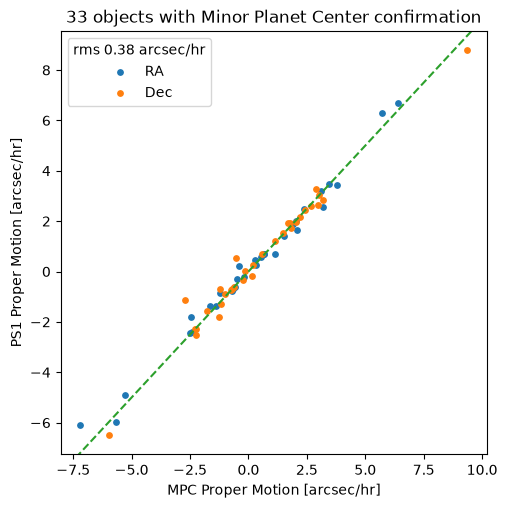

In [8]:
# Read in verified object aggregate table:
verified_objects = Table.read('q15-confirmed.ecsv')

# Plot PS1 versus JPL proper motions, which have been converted to units of arcsec/hour
f, ax = plt.subplots(figsize=(5.5, 5.5))
rmsarr = []
for key in ["RA", "Dec"]:
    ax.scatter(
        verified_objects[f"{key.lower()}pm"], # JPL/MPC values
        verified_objects[f"pm{key.lower()}"], # PS1 values
        label=key,
        s=15,
    )
    rmsarr.extend(
        verified_objects[f"pm{key.lower()}"]
        - verified_objects[f"{key.lower()}pm"]
    )
# Plot 1:1 line:
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.plot(
    [np.min([xlim[0], ylim[0]]), np.max([xlim[1], ylim[1]])], 
    [np.min([xlim[0], ylim[0]]), np.max([xlim[1], ylim[1]])], 
    ls="--", color="tab:green", 
)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Calculate RMS:
rms = np.sqrt(np.average(np.array(rmsarr)**2))
ax.legend(title=f"rms {rms:0.2f} arcsec/hr")
ax.set_xlabel("MPC Proper Motion [arcsec/hr]")
ax.set_ylabel("PS1 Proper Motion [arcsec/hr]")
_ = ax.set_title("33 objects with Minor Planet Center confirmation")

We see there is excellent agreement between the PS1 proper motions and the JPL proper motions.  That provides support for this approach as a useful way to find moving objects.

------

## Conclusions

This query demonstrates how to leverage MAST's PS1 TAP service to identify objects with multiple epoch detections by joining tables and computing aggregate properties to select objects using ADQL queries.

See the full MAST [PanSTARRS tutorial list](../../panstarrs.md) for more tutorials demonstrating how to access PanSTARRS catalogs and other select "20 queries" examples.

----------

## Additional Resources

### Table Access Protocol

- IVOA standard for RESTful web service access to tabular data
- http://www.ivoa.net/documents/TAP/

### PanSTARRS 1 DR 2

- https://outerspace.stsci.edu/display/PANSTARRS/
- [Migration guide from legacy to new PS1 TAP service](https://outerspace.stsci.edu/x/DIFeGg)

### Astronomical Query Data Language (2.0)

- IVOA standard for querying astronomical data in tabular format, with geometric search support
- http://www.ivoa.net/documents/latest/ADQL.html

### PyVO

- an affiliated package for [astropy](https://www.astropy.org/)
- find and retrieve astronomical data available from archives that support standard IVOA virtual observatory service protocols.
- https://pyvo.readthedocs.io/en/latest/index.html


### Full list of MAST/TAP services
- A full list of available MAST TAP services can be found at:
- https://mast.stsci.edu/vo-tap


## Citations
If you use `astropy` for published research, please cite the
authors. Follow these links for more information about citing `astropy`:

* [Citing `astropy`](https://www.astropy.org/acknowledging.html)

If you use PanSTARRS data accessed through MAST for published research, 
please include the following acknowledgements, found at the following links:

* [Acknowledging PanSTARRS](https://archive.stsci.edu/publishing/mission-acknowledgements#section-895d38a0-86b3-4143-b521-6cc3312701f9)
* [Acknowledging MAST](https://archive.stsci.edu/gsc/mast_data_use.html)


## About this Notebook


**Author(s):**  Rick White, Sedona Price<br>
**Keyword(s):** Tutorial, TAP, pyvo, ADQL, Pan-STARRS <br>
**Last Updated:** October 2026
***
[Top of Page](#top)
<img style="float: right;" src="https://raw.githubusercontent.com/spacetelescope/style-guides/master/guides/images/stsci-logo.png" alt="Space Telescope Logo" width="200px"/> 